In [1]:
import numpy as np
import random

In [2]:
# ==========================================
# 1. ENVIRONMENT SETUP
# ==========================================
GRID_SIZE = 3
START_STATE = (0, 0)
GOAL_STATE = (2, 2)  # Reward: +10
HOLE_STATE = (1, 1)  # Reward: -10 (Terminal state)

# Actions: 0=Up, 1=Right, 2=Down, 3=Left
NUM_ACTIONS = 4

q_table = np.zeros((GRID_SIZE, GRID_SIZE, NUM_ACTIONS))

In [3]:
# ==========================================
# 2. HYPERPARAMETERS
# ==========================================
ALPHA = 0.1     # Learning Rate
GAMMA = 0.9     # Discount Factor
EPSILON = 0.1   # Exploration Rate
EPISODES = 10000 # Increased because slipping makes learning harder!

In [4]:
# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def take_action(state, intended_action):
    """
    Applies the slippery 'Frozen Lake' physics.
    80% chance to move in the intended direction.
    10% chance to slip 90 degrees to the left.
    10% chance to slip 90 degrees to the right.
    """
    roll = random.uniform(0, 1)
    
    if roll < 0.80:
        actual_action = intended_action
    elif roll < 0.90:
        # Slip counter-clockwise (e.g., intended Up(0) -> slips Left(3))
        actual_action = (intended_action - 1) % 4
    else:
        # Slip clockwise (e.g., intended Up(0) -> slips Right(1))
        actual_action = (intended_action + 1) % 4

    # Now execute the actual movement
    r, c = state
    if actual_action == 0 and r > 0:               r -= 1  # Move Up
    elif actual_action == 1 and c < GRID_SIZE - 1: c += 1  # Move Right
    elif actual_action == 2 and r < GRID_SIZE - 1: r += 1  # Move Down
    elif actual_action == 3 and c > 0:             c -= 1  # Move Left
    
    return (r, c)

def get_reward(state):
    """Returns the reward for stepping into a state."""
    if state == GOAL_STATE: return 10
    if state == HOLE_STATE: return -10
    return -1


In [5]:
# ==========================================
# 4. THE Q-LEARNING ALGORITHM
# ==========================================
for episode in range(EPISODES):
    state = START_STATE
    
    # Loop ends if agent reaches the Goal OR falls in the Hole
    while state != GOAL_STATE and state != HOLE_STATE:
        
        # A. Choose action (Epsilon-Greedy)
        if random.uniform(0, 1) < EPSILON:
            action = random.choice([0, 1, 2, 3])
        else:
            action = np.argmax(q_table[state[0], state[1]])
            
        # B. Take the step (The environment applies the slip physics here!)
        next_state = take_action(state, action)
        reward = get_reward(next_state)
        
        # C. Q-Table Update (Bootstrapping)
        old_value = q_table[state[0], state[1], action]
        
        # If the next state is game over (goal or hole), there are no future rewards
        if next_state == GOAL_STATE or next_state == HOLE_STATE:
            next_max = 0
        else:
            next_max = np.max(q_table[next_state[0], next_state[1]])
            
        # Bellman Equation
        new_value = old_value + ALPHA * (reward + (GAMMA * next_max) - old_value)
        q_table[state[0], state[1], action] = new_value
        
        # D. Move to next state
        state = next_state


In [6]:
# ==========================================
# 5. VISUALIZING THE RESULTS
# ==========================================
print("Training Complete! Here is the Agent's Map:")
print("-" * 50)

actions_symbols = ['↑', '→', '↓', '←']

for r in range(GRID_SIZE):
    row_visual = []
    for c in range(GRID_SIZE):
        if (r, c) == GOAL_STATE:
            row_visual.append("[  GOAL  ]")
        elif (r, c) == HOLE_STATE:
            row_visual.append("[  HOLE  ]")
        else:
            best_action = np.argmax(q_table[r, c])
            best_value = np.max(q_table[r, c])
            row_visual.append(f"[{actions_symbols[best_action]}: {best_value:>+5.1f}]")
            
    print("  ".join(row_visual))
    print("")

Training Complete! Here is the Agent's Map:
--------------------------------------------------
[↓:  -0.2]  [→:  +1.4]  [↓:  +4.6]

[↓:  +2.0]  [  HOLE  ]  [↓:  +7.1]

[→:  +6.0]  [→:  +9.2]  [  GOAL  ]



C:\Users\jithi\AppData\Local\Temp\ipykernel_29308\1316164629.py:102: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jithi\AppData\Local\Temp\ipykernel_29308\1316164629.py:102: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


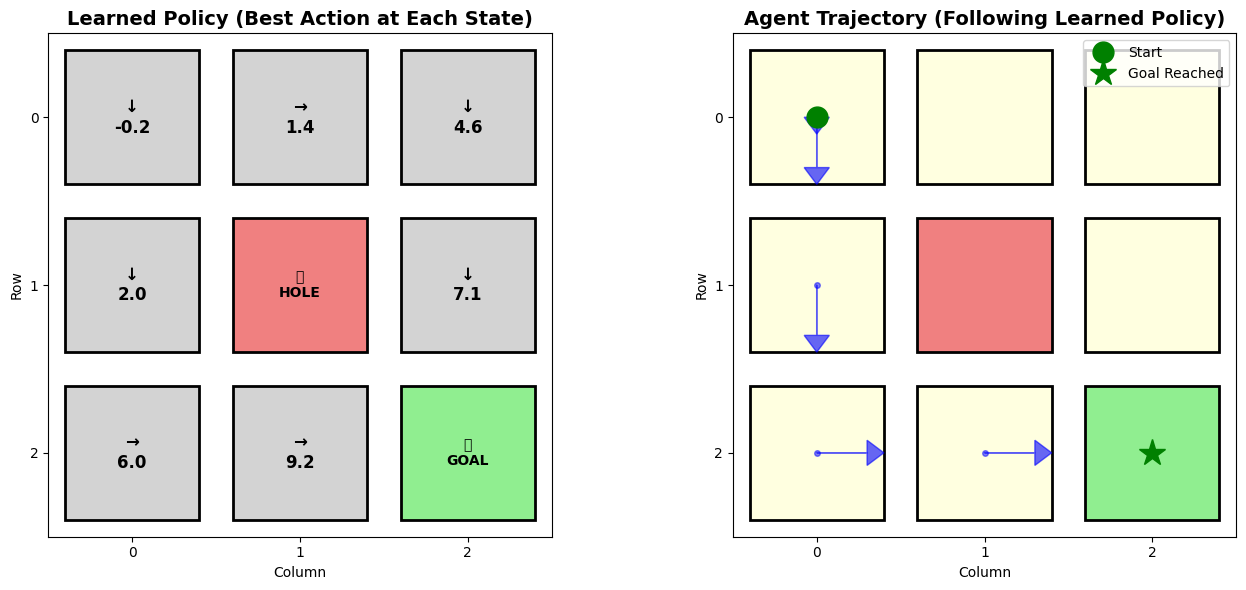


Agent's Trajectory: (0, 0) → (0, 0) → (1, 0) → (2, 0) → (2, 1) → (2, 2)
Episode Length: 5 steps
Final State: (2, 2) (GOAL!)


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# 6. VISUALIZE AGENT MOVEMENT WITH MATPLOTLIB
# ==========================================

# Run a test episode to get the agent's trajectory
trajectory = []
state = START_STATE
trajectory.append(state)

# Follow the learned policy (greedy) for one episode
steps = 0
max_steps = 20  # Prevent infinite loops

while state != GOAL_STATE and state != HOLE_STATE and steps < max_steps:
    action = np.argmax(q_table[state[0], state[1]])
    state = take_action(state, action)
    trajectory.append(state)
    steps += 1

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT PLOT: Policy Visualization ---
ax1.set_xlim(-0.5, GRID_SIZE - 0.5)
ax1.set_ylim(-0.5, GRID_SIZE - 0.5)
ax1.set_aspect('equal')
ax1.invert_yaxis()
ax1.set_title('Learned Policy (Best Action at Each State)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Column')
ax1.set_ylabel('Row')
ax1.set_xticks(range(GRID_SIZE))
ax1.set_yticks(range(GRID_SIZE))

# Draw grid
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        rect = patches.Rectangle((c - 0.4, r - 0.4), 0.8, 0.8, 
                                 linewidth=2, edgecolor='black', facecolor='lightgray')
        ax1.add_patch(rect)
        
        # Add best action arrow
        if (r, c) != GOAL_STATE and (r, c) != HOLE_STATE:
            best_action = np.argmax(q_table[r, c])
            best_value = np.max(q_table[r, c])
            ax1.text(c, r, f'{actions_symbols[best_action]}\n{best_value:.1f}', 
                    ha='center', va='center', fontsize=12, fontweight='bold')
        elif (r, c) == GOAL_STATE:
            rect.set_facecolor('lightgreen')
            ax1.text(c, r, '🎯\nGOAL', ha='center', va='center', fontsize=10, fontweight='bold')
        elif (r, c) == HOLE_STATE:
            rect.set_facecolor('lightcoral')
            ax1.text(c, r, '❌\nHOLE', ha='center', va='center', fontsize=10, fontweight='bold')

# --- RIGHT PLOT: Agent Trajectory ---
ax2.set_xlim(-0.5, GRID_SIZE - 0.5)
ax2.set_ylim(-0.5, GRID_SIZE - 0.5)
ax2.set_aspect('equal')
ax2.invert_yaxis()
ax2.set_title('Agent Trajectory (Following Learned Policy)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Column')
ax2.set_ylabel('Row')
ax2.set_xticks(range(GRID_SIZE))
ax2.set_yticks(range(GRID_SIZE))

# Draw grid
for r in range(GRID_SIZE):
    for c in range(GRID_SIZE):
        rect = patches.Rectangle((c - 0.4, r - 0.4), 0.8, 0.8, 
                                 linewidth=2, edgecolor='black', facecolor='lightyellow')
        ax2.add_patch(rect)
        
        if (r, c) == GOAL_STATE:
            rect.set_facecolor('lightgreen')
        elif (r, c) == HOLE_STATE:
            rect.set_facecolor('lightcoral')

# Plot trajectory path
if len(trajectory) > 1:
    for i in range(len(trajectory) - 1):
        x1, y1 = trajectory[i][1], trajectory[i][0]
        x2, y2 = trajectory[i + 1][1], trajectory[i + 1][0]
        ax2.arrow(x1, y1, (x2 - x1) * 0.3, (y2 - y1) * 0.3, 
                 head_width=0.15, head_length=0.1, fc='blue', ec='blue', alpha=0.6)

# Mark start, intermediate, and goal positions
for i, (r, c) in enumerate(trajectory):
    if i == 0:
        ax2.plot(c, r, 'go', markersize=15, label='Start', zorder=5)
    elif (r, c) == trajectory[-1]:
        if trajectory[-1] == GOAL_STATE:
            ax2.plot(c, r, 'g*', markersize=20, label='Goal Reached', zorder=5)
        else:
            ax2.plot(c, r, 'rx', markersize=15, label='Episode Ended', zorder=5)
    else:
        ax2.plot(c, r, 'b.', markersize=8, alpha=0.5, zorder=4)

ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nAgent's Trajectory: {' → '.join([str(s) for s in trajectory])}")
print(f"Episode Length: {len(trajectory) - 1} steps")
print(f"Final State: {trajectory[-1]} {'(GOAL!)' if trajectory[-1] == GOAL_STATE else '(Game Over)'}")
